### News Analysis Data Extraction
Extracts article data from csv file
This will probably turn into a .py file to extract data later but just playing around right now

In [34]:
import pandas as pd

japan_english_filepath = "../../project/data/raw/japan_english_news_kaggle.csv"
JPnews_pd = pd.read_csv(japan_english_filepath, sep='\t') # set delimiter to tab
JPnews_pd.head(10)

,source,date,title,author,text
0,Mainichi Shimbun,2021-12-06,"Editorial: Japan govt's 20,000-yen handout mis...",NaN,The Japanese government is trying to boost the...
1,Mainichi Shimbun,2021-12-07,Editorial: Time for Japan PM Kishida to delive...,NaN,"Prime Minister Fumio Kishida, who won a public..."
2,Mainichi Shimbun,2021-12-08,"Editorial: 80 years on from Pearl Harbor, acti...",NaN,It has been 80 years since the start of the Pa...
3,Mainichi Shimbun,2021-12-08,"Yoroku: 80 years later, many lessons still not...",NaN,"""The world has changed completely. The era was..."
4,Mainichi Shimbun,2021-12-08,Promoting respect for human rights behind US '...,NaN,The U.S. administration under President Joe Bi...
5,Mainichi Shimbun,2021-12-09,News Navigator: What is 'Olympic diplomacy'?,NaN,The Mainichi Shimbun answers some common quest...
6,Mainichi Shimbun,2021-12-09,Editorial: Japan's main opposition CDP has tur...,NaN,"During party leaders' questions, which began a..."
7,Mainichi Shimbun,2021-12-10,News Navigator: How does the Japanese-develope...,NaN,The Mainichi Shimbun answers some common quest...
8,Mainichi Shimbun,2021-12-10,Editorial: Japan PM's response weak on 1 mil. ...,NaN,Calls have arisen for a review of a 1 million ...
9,Mainichi Shimbun,2021-12-11,Edging Toward Japan: Inspiration from Anpan Ma...,By,"Recently, my 9-year-old daughter mentioned in ..."


In [35]:
JPnews_pd.columns

Index(['source', 'date', 'title', 'author', 'text'], dtype='object')

In [36]:
# Index by date
JPnews_pd_indexed = JPnews_pd.set_index('date')
JPnews_pd_indexed.head(10)

,source,title,author,text
date,,,,
2021-12-06,Mainichi Shimbun,"Editorial: Japan govt's 20,000-yen handout mis...",NaN,The Japanese government is trying to boost the...
2021-12-07,Mainichi Shimbun,Editorial: Time for Japan PM Kishida to delive...,NaN,"Prime Minister Fumio Kishida, who won a public..."
2021-12-08,Mainichi Shimbun,"Editorial: 80 years on from Pearl Harbor, acti...",NaN,It has been 80 years since the start of the Pa...
2021-12-08,Mainichi Shimbun,"Yoroku: 80 years later, many lessons still not...",NaN,"""The world has changed completely. The era was..."
2021-12-08,Mainichi Shimbun,Promoting respect for human rights behind US '...,NaN,The U.S. administration under President Joe Bi...
2021-12-09,Mainichi Shimbun,News Navigator: What is 'Olympic diplomacy'?,NaN,The Mainichi Shimbun answers some common quest...
2021-12-09,Mainichi Shimbun,Editorial: Japan's main opposition CDP has tur...,NaN,"During party leaders' questions, which began a..."
2021-12-10,Mainichi Shimbun,News Navigator: How does the Japanese-develope...,NaN,The Mainichi Shimbun answers some common quest...
2021-12-10,Mainichi Shimbun,Editorial: Japan PM's response weak on 1 mil. ...,NaN,Calls have arisen for a review of a 1 million ...


In [37]:
# Sort by date
JPnews_pd_indexed = JPnews_pd_indexed.sort_index()
JPnews_pd_indexed.head(10)

,source,title,author,text
date,,,,
2001-01-01,The Japan Times,Life? Martian meteorite keeps its cool,Rowan Hooper,"“X-Files,” eat your heart out. Supporters of t..."
2001-01-01,The Japan Times,Economy expected to limp toward recovery,Mayumi Negishi,The consensus among economists at private thin...
2001-01-01,The Japan Times,State-backed Internet expo kicks off,NaN,The government-sponsored virtual Internet expo...
2001-01-01,The Japan Times,Foreign workforce movin' on up,Tetsushi Kajimoto,"For a long time, workers coming to Japan from ..."
2001-01-01,The Japan Times,Can peace be globalized in the 21st century?,Yoshikazu Sakamoto,The 20th century is usually referred to as a c...
2001-01-01,The Japan Times,A question of hegemony,William Pfaff,An implicit alliance has emerged in Washington...
2001-01-01,The Japan Times,Wanted: a leadership strategy,Takeshi Sasaki,Japan has stepped into the 21st century under ...
2001-01-01,The Japan Times,Man held for allegedly stabbing wife to death,NaN,Police on Sunday arrested on suspicion of murd...
2001-01-01,The Japan Times,Toward mutually assured peace,Toshiyuki Toyoda,"As we enter the 21st century, recent trends in..."


In [38]:
# Drop na values in text
JPnews_pd_indexed.dropna(subset=['text'], inplace=True)
JPnews_pd_indexed.head(10)

,source,title,author,text
date,,,,
2001-01-01,The Japan Times,Life? Martian meteorite keeps its cool,Rowan Hooper,"“X-Files,” eat your heart out. Supporters of t..."
2001-01-01,The Japan Times,Economy expected to limp toward recovery,Mayumi Negishi,The consensus among economists at private thin...
2001-01-01,The Japan Times,State-backed Internet expo kicks off,NaN,The government-sponsored virtual Internet expo...
2001-01-01,The Japan Times,Foreign workforce movin' on up,Tetsushi Kajimoto,"For a long time, workers coming to Japan from ..."
2001-01-01,The Japan Times,Can peace be globalized in the 21st century?,Yoshikazu Sakamoto,The 20th century is usually referred to as a c...
2001-01-01,The Japan Times,A question of hegemony,William Pfaff,An implicit alliance has emerged in Washington...
2001-01-01,The Japan Times,Wanted: a leadership strategy,Takeshi Sasaki,Japan has stepped into the 21st century under ...
2001-01-01,The Japan Times,Man held for allegedly stabbing wife to death,NaN,Police on Sunday arrested on suspicion of murd...
2001-01-01,The Japan Times,Toward mutually assured peace,Toshiyuki Toyoda,"As we enter the 21st century, recent trends in..."


In [39]:
# Count number of total articles
indexed_numrows = len(JPnews_pd_indexed)
indexed_numrows

36766

In [40]:
# Use indexed and sorted data to search for articles that contain the keyword "deflation" in them
JPnews_pd_keyword = JPnews_pd_indexed[JPnews_pd_indexed['text'].str.contains('deflation', case=False)]
JPnews_pd_keyword.head(10)

,source,title,author,text
date,,,,
2001-02-19,The Japan Times,G7 finance ministers urge Japan to combat defl...,NaN,"PALERMO, Italy –Japan’s counterparts from the ..."
2001-03-06,The Japan Times,State may redefine 'deflation',NaN,The central government is considering relaxing...
2001-03-17,The Japan Times,State of deflation declared as assessment is d...,NaN,The government on Friday downgraded its overal...
2001-03-21,The Japan Times,Welcome return to zero-interest rates,NaN,In yet another move to roll back deflationary ...
2001-03-23,The Japan Times,Hayami lauds BOJ's strategy,NaN,Bank of Japan Gov. Masaru Hayami said Thursday...
2001-03-31,The Japan Times,Tokyo's prices sank record 0.9% in 2000,NaN,Consumer prices in Tokyo fell a record 0.9 per...
2001-04-04,The Japan Times,Pundits reckon 15% sales tax ought to nip defl...,NaN,The problem of falling prices should be handle...
2001-04-10,The Japan Times,Reasons to thank Mr. Mori,Takamitsu Sawa,"Since he took office a year ago, Prime Ministe..."
2001-05-02,The Japan Times,REITs banked on to ease market fears,Yosuke Naito,As stock market woes and asset deflation conti...


In [41]:
# Count number of articles that contain keyword (compared to the total 12724)
keyword_numrows = len(JPnews_pd_keyword)
keyword_numrows

235

## Count Function

Define a function to get article count containing keyword - start of migrating to .py files

In [42]:
def keyword_article_count(keyword):
    japan_english_filepath = "../../project/data/clean/Japan_cleaned_news.csv"
    JPnews_pd = pd.read_csv(japan_english_filepath)

    JPnews_pd_keyword = JPnews_pd_indexed[JPnews_pd_indexed['text'].str.contains(keyword, case=False)]
    keyword_rows = len(JPnews_pd_keyword)

    return keyword_rows

keyword_article_count('deflation')

235

## Graph Function

Define a function to graph article with keyword occurences over time

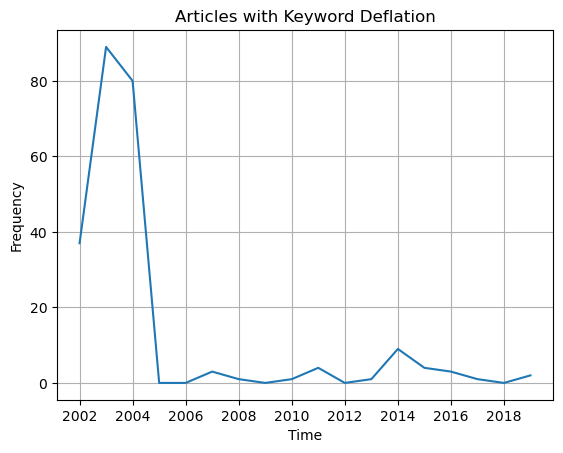

In [47]:
def article_graph(keyword, x_title, y_title, main_title):
    japan_english_filepath = "../../project/data/clean/Japan_cleaned_news.csv"
    JPnews_pd = pd.read_csv(japan_english_filepath, index_col='date', parse_dates=True)

    JPnews_pd_keyword = JPnews_pd[JPnews_pd['text'].str.contains(keyword, case=False)]

    df_plot = JPnews_pd_keyword.resample('YE').size()

    fig, ax = plt.subplots()
    ax.plot(df_plot.index, df_plot.values)
    ax.set_xlabel(x_title)
    ax.set_ylabel(y_title)
    ax.set_title(main_title)
    ax.grid(True)
    
    return fig

# Save the figure
deflation_graph = article_graph('deflation', 'Time', 'Frequency', 'Articles with Keyword Deflation')
deflation_graph.savefig('deflation_articles_plot.png', bbox_inches='tight', dpi=300)
plt.show()

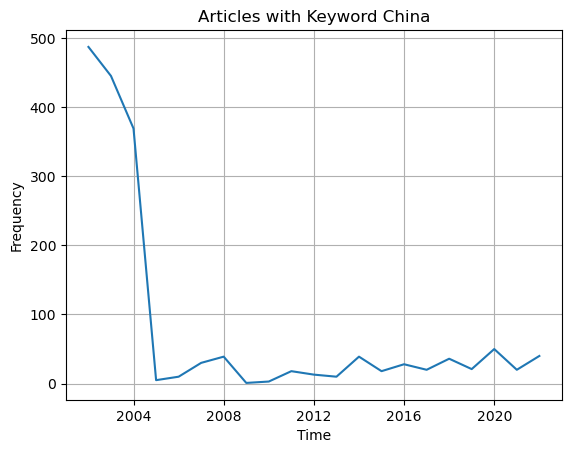

In [53]:
china_graph = article_graph('china', 'Time', 'Frequency', 'Articles with Keyword China')
china_graph.savefig('china_articles_plot.png', bbox_inches='tight', dpi=300)
plt.show()

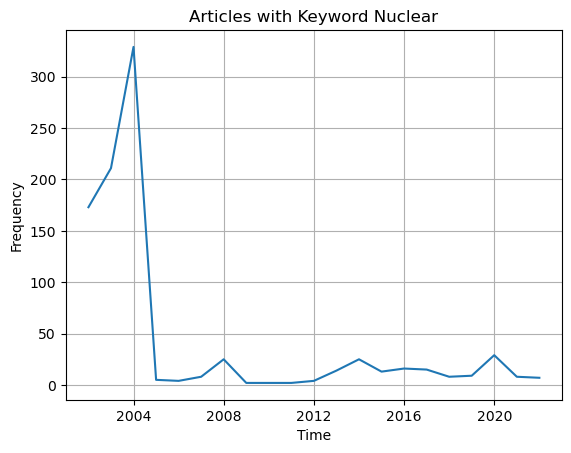

In [54]:
nuclear_graph = article_graph('nuclear', 'Time', 'Frequency', 'Articles with Keyword Nuclear')
nuclear_graph.savefig('nuclear_articles_plot.png', bbox_inches='tight', dpi=300)
plt.show()

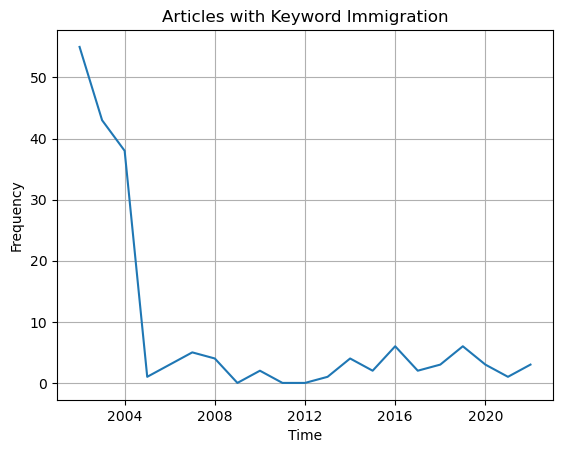

In [55]:
immigration_graph = article_graph('immigration', 'Time', 'Frequency', 'Articles with Keyword Immigration')
immigration_graph.savefig('immigration_articles_plot.png', bbox_inches='tight', dpi=300)
plt.show()

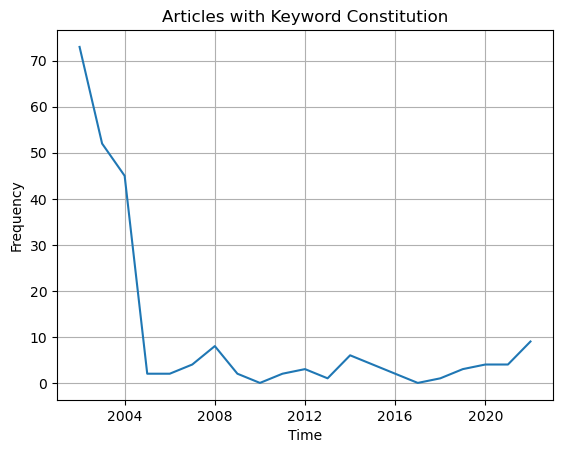

In [56]:
constitution_graph = article_graph('constitution', 'Time', 'Frequency', 'Articles with Keyword Constitution')
constitution_graph.savefig('Constitution_articles_plot.png', bbox_inches='tight', dpi=300)
plt.show()

## Notes

It looks like pre-2004 has much more articles and we should consider this period an outlier that skews our results and just cut it out. Maybe begin our timeline from 2005?